A smart city authority is designing an intelligent transportation and public-service recommendation system. The city has several intersections connected by roads. Each intersection is represented as a vertex, and each road is represented as an edge. The authority wants to analyze road connectivity, check whether the road network can be drawn on a 2D map without crossings, and identify important intersections. At the same time, citizens visit different public facilities such as hospitals, schools, parks, and markets. These visits are represented as a bipartite graph, where one set of nodes represents citizens and the other set represents facilities. The number of visits or satisfaction score is used as an edge weight. The authority wants to cluster citizens based on their facility usage patterns.Part A: Road Network Graph AnalysisThe road network is given as:Vertices:V = {A, B, C, D, E, F}Edges:E = {(A,B), (A,C), (B,C), (B,D), (C,E), (D,E), (D,F), (E,F)}Tasks:
a) Construct the road network using Python.
b) Generate the adjacency matrix.
c) Generate the incidence matrix.
d) Visualize the graph.e) Check whether the graph is planar.
f)Use Euler's formula V-E+F=2 to calculate the number of faces.
g) Find the eccentricity of each vertex.
h) Determine diameter, radius, center, and peripheral nodes.
i) Add one extra edge and analyze the change in diameter and radius.

In [2]:
#(a) Construct the road network using Python.
import networkx as nx
import matplotlib.pyplot as plt

vertices = ['A','B','C','D','E','F']

edges = [
    ('A','B'),
    ('A','C'),
    ('B','C'),
    ('B','D'),
    ('C','E'),
    ('D','E'),
    ('D','F'),
    ('E','F')
]

G = nx.Graph()

G.add_nodes_from(vertices)
G.add_edges_from(edges)

In [3]:
# b) Generate the adjacency matrix
adj = nx.to_pandas_adjacency(G, dtype=int)
print(adj)

   A  B  C  D  E  F
A  0  1  1  0  0  0
B  1  0  1  1  0  0
C  1  1  0  0  1  0
D  0  1  0  0  1  1
E  0  0  1  1  0  1
F  0  0  0  1  1  0


In [7]:
# c) Generate the incidence matrix.
import pandas as pd
inc = nx.incidence_matrix(G, oriented=False)

inc_df = pd.DataFrame(
    inc.toarray().astype(int),
    index=vertices,
    columns=[f"e{i+1}" for i in range(len(edges))]
)

print(inc_df)

   e1  e2  e3  e4  e5  e6  e7  e8
A   1   1   0   0   0   0   0   0
B   1   0   1   1   0   0   0   0
C   0   1   1   0   1   0   0   0
D   0   0   0   1   0   1   1   0
E   0   0   0   0   1   1   0   1
F   0   0   0   0   0   0   1   1


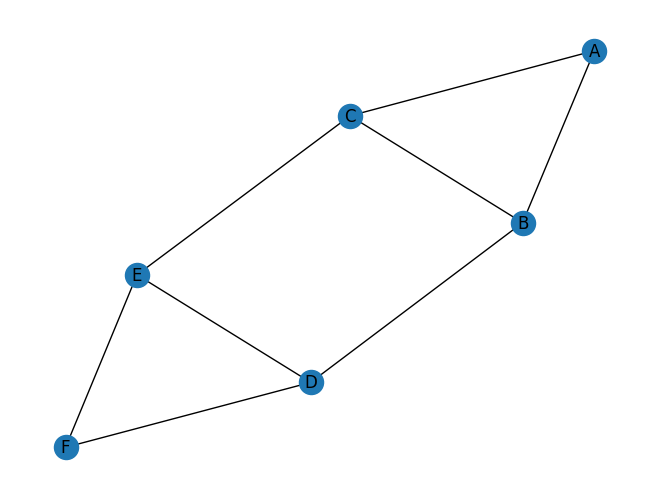

In [20]:
# d) Visualize the graph

nx.draw(G, with_labels=True)
plt.show()

In [22]:
# e) Check whether the graph is planar.
is_planar, embedding = nx.check_planarity(G)

print(is_planar)

True


In [23]:
# (f) Use Euler's formula V-E+F=2 to calculate the number of faces.
V=6
E=8
F = E - V + 2                              # Euler formula( V - E + F = 2 ) # Face and region same


print("F =", F)



F = 4


In [24]:
# (g) Find the eccentricity of each vertex.
eccentricity = nx.eccentricity(G)
print(eccentricity)

{'A': 3, 'B': 2, 'C': 2, 'D': 2, 'E': 2, 'F': 3}


In [29]:
#(h) Determine diameter, radius, center, and peripheral nodes.
diameter = nx.diameter(G)
radius = nx.radius(G)
center = nx.center(G)
peripheral = nx.periphery(G)

print("Diameter:", diameter)
print("Radius:", radius)
print("Center:", center)
print("Peripheral:", peripheral)


Diameter: 3
Radius: 2
Center: ['B', 'C', 'D', 'E']
Peripheral: ['A', 'F']


In [31]:
#(i) Add one extra edge and analyze the change in diameter and radius
G.add_edge('A','F')
print("Diameter =", nx.diameter(G))
print("Radius =", nx.radius(G))

Diameter = 2
Radius = 2
